# Mini Project 01 — Titanic Classification
## Section C — Library Implementations (scikit-learn)

**Deliverable:** `C_library_models.ipynb`

The same algorithms as Section B, now with scikit-learn, evaluated on the **identical split** (from Section A) with the **identical metrics**, followed by a head-to-head comparison against the from-scratch results saved by Section B.

| Family | Library models |
|---|---|
| Logistic regression | `LogisticRegression` — no penalty · L1 · L2 |
| Bagging | `RandomForestClassifier` (+ `BaggingClassifier` of trees as an apples-to-apples control for Section B) |
| Boosting (≥ 3) | `AdaBoostClassifier` · `GradientBoostingClassifier` · `HistGradientBoostingClassifier` |

> **Run order:** A → B → C (C reads `data/processed/titanic_split.npz` from A and `data/results/results_B.json` from B).

In [1]:
import os, time, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
                             matthews_corrcoef, balanced_accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)

SEED = 42                                   # same global seed as Sections A and B
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
os.makedirs("figs", exist_ok=True); os.makedirs("data/results", exist_ok=True)
print("Python", platform.python_version(), "| numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
NB_START = time.perf_counter()

Python 3.12.3 | numpy 2.4.4 | pandas 3.0.2 | scikit-learn 1.8.0 | matplotlib 3.10.8


## 1. Load the identical split (Section A) and the from-scratch results (Section B)

In [2]:
d = np.load("data/processed/titanic_split.npz")
X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]
feature_names = [str(f) for f in d["feature_names"]]
with open("data/results/results_B.json") as fh: RB = json.load(fh)

assert RB["seed"] == SEED and RB["n_train"] == len(y_train) and RB["n_test"] == len(y_test)   # same split & seed as B
print("X_train", X_train.shape, "X_test", X_test.shape, "| B-results loaded for:", list(RB["metrics"]))

X_train (712, 9) X_test (179, 9) | B-results loaded for: ['LogReg (none)', 'LogReg (L1)', 'LogReg (L2)', 'Bagging (trees)', 'AdaBoost (stumps)']


## 2. Shared evaluation function (same metrics as Section B)
Accuracy · precision · recall · F1 · specificity-based balanced accuracy · MCC · ROC-AUC · average precision · log-loss, a confusion matrix and the ROC / PR curves. Threshold = 0.5, as in Section B.

**Fair tuning protocol.** Every tunable library model is tuned with `GridSearchCV` on the **training set only** — 5-fold `StratifiedKFold(shuffle=True, random_state=42)`, scored by ROC-AUC (the same criterion as in Section B). The logistic-regression grid is the *same λ grid* as B, expressed through `C = 1/(n·λ)` (this is exactly the mapping between B's objective and scikit-learn's).

In [3]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluate(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"accuracy": accuracy_score(y_true, y_pred), "precision": precision_score(y_true, y_pred), "recall": recall_score(y_true, y_pred),
            "specificity": tn / (tn + fp), "f1": f1_score(y_true, y_pred), "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "mcc": matthews_corrcoef(y_true, y_pred), "roc_auc": roc_auc_score(y_true, y_prob),
            "avg_precision": average_precision_score(y_true, y_prob), "log_loss": log_loss(y_true, y_prob)}

n = len(y_train)
LAM_GRID = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001, 0.0003]          # identical to Section B
C_GRID = [1.0 / (n * lam) for lam in LAM_GRID]

lib_models, best_params, cv_auc = {}, {}, {}
fit_times, probs, preds, results = {}, {}, {}, {}

def run(name, estimator, grid=None):
    t0 = time.perf_counter()
    if grid:
        gs = GridSearchCV(estimator, grid, scoring="roc_auc", cv=CV, n_jobs=1).fit(X_train, y_train)
        model, best_params[name], cv_auc[name] = gs.best_estimator_, gs.best_params_, float(gs.best_score_)
    else:
        model = estimator.fit(X_train, y_train); cv_auc[name] = float(cross_val_score(estimator, X_train, y_train, cv=CV, scoring="roc_auc").mean()); best_params[name] = {}
    fit_times[name] = time.perf_counter() - t0
    lib_models[name] = model
    probs[name] = model.predict_proba(X_test)[:, 1]
    preds[name] = (probs[name] >= 0.5).astype(int)                       # same 0.5 threshold as Section B
    results[name] = evaluate(y_test, preds[name], probs[name])
    print(f"{name:<24} CV-AUC={cv_auc[name]:.4f}  test-acc={results[name]['accuracy']:.4f}  test-AUC={results[name]['roc_auc']:.4f}  params={best_params[name]}  ({fit_times[name]:.1f}s)")

## 3. Logistic regression — no regularisation, L1, L2

In [4]:
warnings.filterwarnings("ignore")        # saga/lbfgs convergence chatter; max_iter is generous
run("LogReg (none)", LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000))
run("LogReg (L1)",   LogisticRegression(penalty="l1", solver="saga", max_iter=20000, tol=1e-6, random_state=SEED), {"C": C_GRID})
run("LogReg (L2)",   LogisticRegression(penalty="l2", solver="lbfgs", max_iter=10000), {"C": C_GRID})

for k in ("LogReg (L1)", "LogReg (L2)"):
    C_ = best_params[k]["C"]; print(f"  {k}: selected C={C_:.4f}  ->  equivalent lambda = 1/(nC) = {1/(n*C_):.4f}")

LogReg (none)            CV-AUC=0.8577  test-acc=0.7989  test-AUC=0.8379  params={}  (0.0s)


LogReg (L1)              CV-AUC=0.8579  test-acc=0.8156  test-AUC=0.8436  params={'C': 0.4681647940074906}  (0.3s)
LogReg (L2)              CV-AUC=0.8578  test-acc=0.7989  test-AUC=0.8381  params={'C': 4.681647940074907}  (0.1s)
  LogReg (L1): selected C=0.4682  ->  equivalent lambda = 1/(nC) = 0.0030
  LogReg (L2): selected C=4.6816  ->  equivalent lambda = 1/(nC) = 0.0003


### 3.1 Cross-check: are the from-scratch coefficients the same as scikit-learn's?
Using *the same λ* (via `C = 1/(nλ)`) for the unregularised and L2 models, both implementations minimise the same convex objective, so their coefficients should agree to optimiser tolerance. This is direct evidence of the mathematical accuracy of Section B.

In [5]:
rows = []
lam_B = RB["selected_hyperparameters"]
checks = {"LogReg (none)": LogisticRegression(penalty=None, solver="lbfgs", max_iter=100000, tol=1e-12),
          "LogReg (L2)":   LogisticRegression(penalty="l2", C=1 / (n * lam_B["lambda_l2"]), solver="lbfgs", max_iter=100000, tol=1e-12),
          "LogReg (L1)":   LogisticRegression(penalty="l1", C=1 / (n * lam_B["lambda_l1"]), solver="saga", max_iter=200000, tol=1e-10, random_state=SEED)}
for name, est in checks.items():
    t0 = time.perf_counter(); est.fit(X_train, y_train); t_fit = time.perf_counter() - t0
    wB, bB = np.array(RB["coefficients"][name]), RB["intercepts"][name]
    pB = np.array(RB["test_probabilities"][name]); pL = est.predict_proba(X_test)[:, 1]
    rows.append({"model": name, "max |w_scratch - w_sklearn|": np.max(np.abs(wB - est.coef_[0])), "|b diff|": abs(bB - est.intercept_[0]),
                 "max |p diff| on test": np.max(np.abs(pB - pL)), "label agreement": np.mean((pB >= .5) == (pL >= .5))})
    if name == "LogReg (L2)":      # keep a lambda-matched L2 model for a like-for-like row in the comparison table
        key = "LogReg (L2, lambda=B)"
        probs[key], preds[key], fit_times[key] = pL, (pL >= .5).astype(int), t_fit
        results[key] = evaluate(y_test, preds[key], pL)
chk = pd.DataFrame(rows).set_index("model")
print(chk.to_string(formatters={c: (lambda v: f"{v:.2e}") for c in chk.columns[:3]} | {"label agreement": lambda v: f"{v:.3f}"}))

              max |w_scratch - w_sklearn| |b diff| max |p diff| on test label agreement
model                                                                                  
LogReg (none)                    2.32e-07 3.70e-08             8.91e-08           1.000
LogReg (L2)                      9.89e-08 7.38e-08             4.22e-08           1.000
LogReg (L1)                      1.61e-07 1.45e-07             2.31e-08           1.000


## 4. Bagging — `RandomForestClassifier`
Random forests are bagged trees **plus** random feature sub-sampling at each split. A plain `BaggingClassifier` over trees (no feature sub-sampling) is also included because it is the like-for-like counterpart of the from-scratch bagging in Section B.

In [6]:
run("RandomForest", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1),
    {"max_depth": [3, 4, 5, 6, 8, None], "min_samples_leaf": [1, 3, 5], "max_features": ["sqrt", None]})
run("Bagging (sk, trees)", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED), n_estimators=200, random_state=SEED, n_jobs=1),
    {"estimator__max_depth": [3, 4, 5, 6, 8, 10]})

RandomForest             CV-AUC=0.8795  test-acc=0.8156  test-AUC=0.8382  params={'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3}  (66.1s)


Bagging (sk, trees)      CV-AUC=0.8705  test-acc=0.8045  test-AUC=0.8363  params={'estimator__max_depth': 4}  (10.4s)


## 5. Boosting — three different classifiers
1. **AdaBoost** with decision stumps (library twin of the from-scratch model).
2. **Gradient Boosting** (shallow trees fitted to the gradient of the log-loss).
3. **Histogram-based Gradient Boosting** (binned, LightGBM-style).

In [7]:
run("AdaBoost (sk, stumps)", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=SEED),
    {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0]})
run("GradientBoosting", GradientBoostingClassifier(random_state=SEED),
    {"n_estimators": [50, 100, 200], "learning_rate": [0.03, 0.1], "max_depth": [2, 3], "subsample": [0.8, 1.0]})
run("HistGradientBoosting", HistGradientBoostingClassifier(random_state=SEED, early_stopping=False),
    {"max_iter": [50, 100, 200], "learning_rate": [0.03, 0.1], "max_depth": [2, 3, None], "l2_regularization": [0.0, 1.0]})

AdaBoost (sk, stumps)    CV-AUC=0.8668  test-acc=0.7989  test-AUC=0.8263  params={'learning_rate': 1.0, 'n_estimators': 100}  (6.5s)


GradientBoosting         CV-AUC=0.8854  test-acc=0.7821  test-AUC=0.7987  params={'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}  (11.4s)


HistGradientBoosting     CV-AUC=0.8830  test-acc=0.7989  test-AUC=0.8105  params={'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'max_iter': 200}  (9.7s)


## 6. Test-set results, confusion matrices and curves (library models)

In [8]:
cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "avg_precision", "mcc", "balanced_accuracy", "log_loss"]
res_C = pd.DataFrame(results).T[cols].round(4); res_C["fit_time_s"] = pd.Series(fit_times).round(2)
res_C

,accuracy,precision,recall,f1,roc_auc,avg_precision,mcc,balanced_accuracy,log_loss,fit_time_s
LogReg (none),0.7989,0.7797,0.6667,0.7188,0.8379,0.7882,0.5679,0.7742,0.4670,0.03
LogReg (L1),0.8156,0.8103,0.6812,0.7402,0.8436,0.7948,0.6044,0.7906,0.4642,0.27
LogReg (L2),0.7989,0.7797,0.6667,0.7188,0.8381,0.7889,0.5679,0.7742,0.4669,0.14
"LogReg (L2, lambda=B)",0.8212,0.8364,0.6667,0.7419,0.8378,0.7973,0.6170,0.7924,0.4759,0.00
RandomForest,0.8156,0.8214,0.6667,0.7360,0.8382,0.8204,0.6044,0.7879,0.4665,66.07
"Bagging (sk, trees)",0.8045,0.8696,0.5797,0.6957,0.8363,0.8279,0.5849,0.7626,0.4485,10.45
"AdaBoost (sk, stumps)",0.7989,0.7705,0.6812,0.7231,0.8263,0.7725,0.5688,0.7769,0.6028,6.52
GradientBoosting,0.7821,0.7885,0.5942,0.6777,0.7987,0.7697,0.5298,0.7471,0.5201,11.38
HistGradientBoosting,0.7989,0.8000,0.6377,0.7097,0.8105,0.7830,0.5672,0.7688,0.5112,9.74


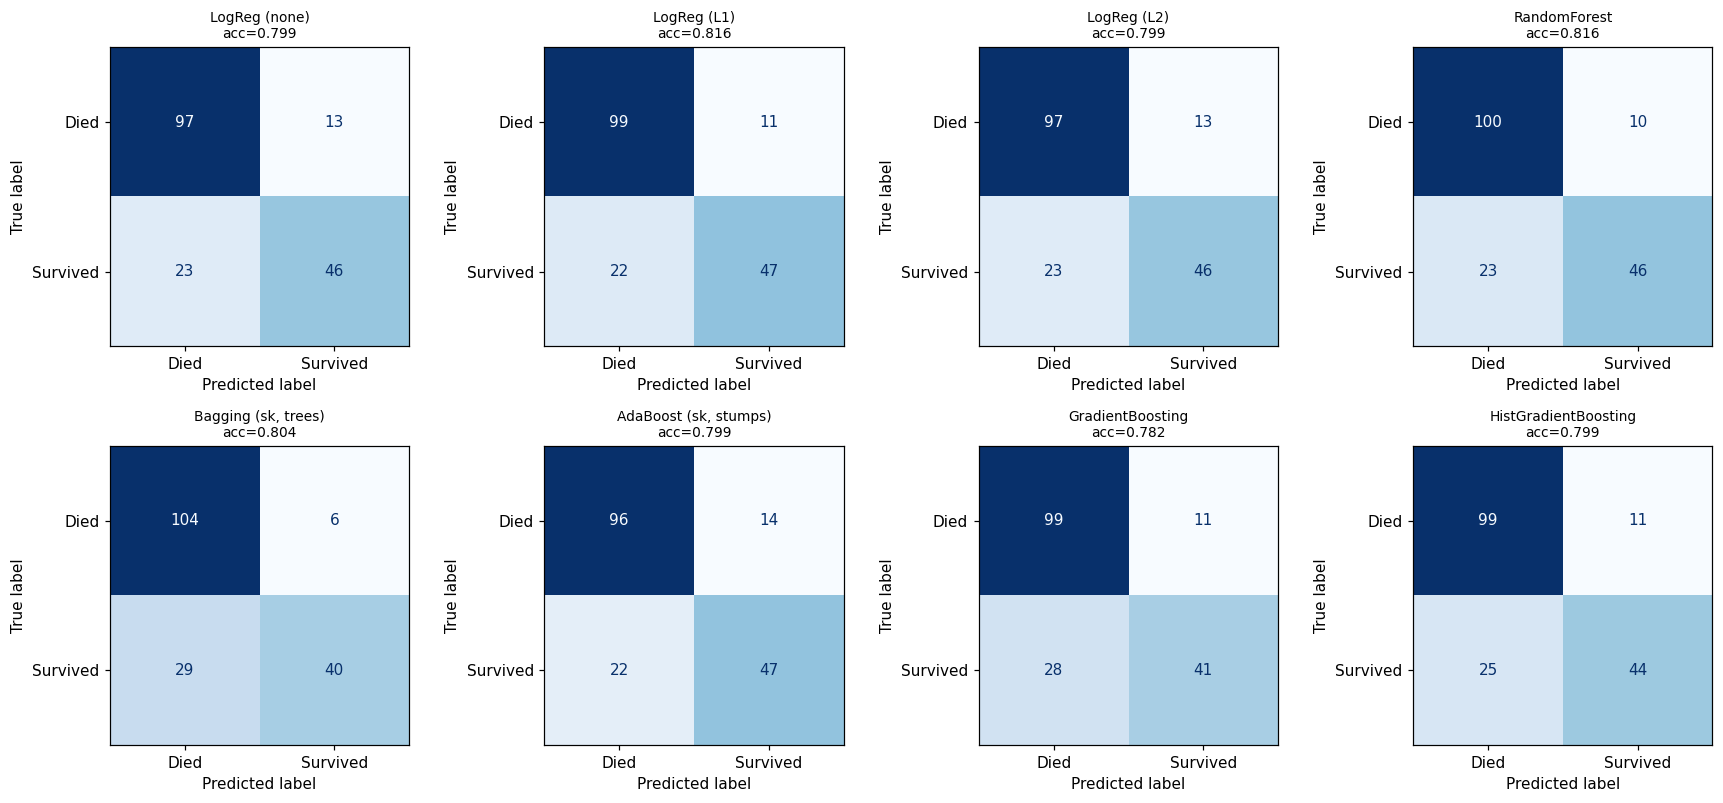

In [9]:
names = list(lib_models)
fig, axes = plt.subplots(2, 4, figsize=(16, 7.4))
for ax, name in zip(axes.ravel(), names):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds[name]), display_labels=["Died", "Survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.grid(False); ax.set_title(f"{name}\nacc={results[name]['accuracy']:.3f}", fontsize=9)
for ax in axes.ravel()[len(names):]: ax.axis("off")
plt.tight_layout(); plt.savefig("figs/C_confusion_matrices.png", bbox_inches="tight"); plt.show()

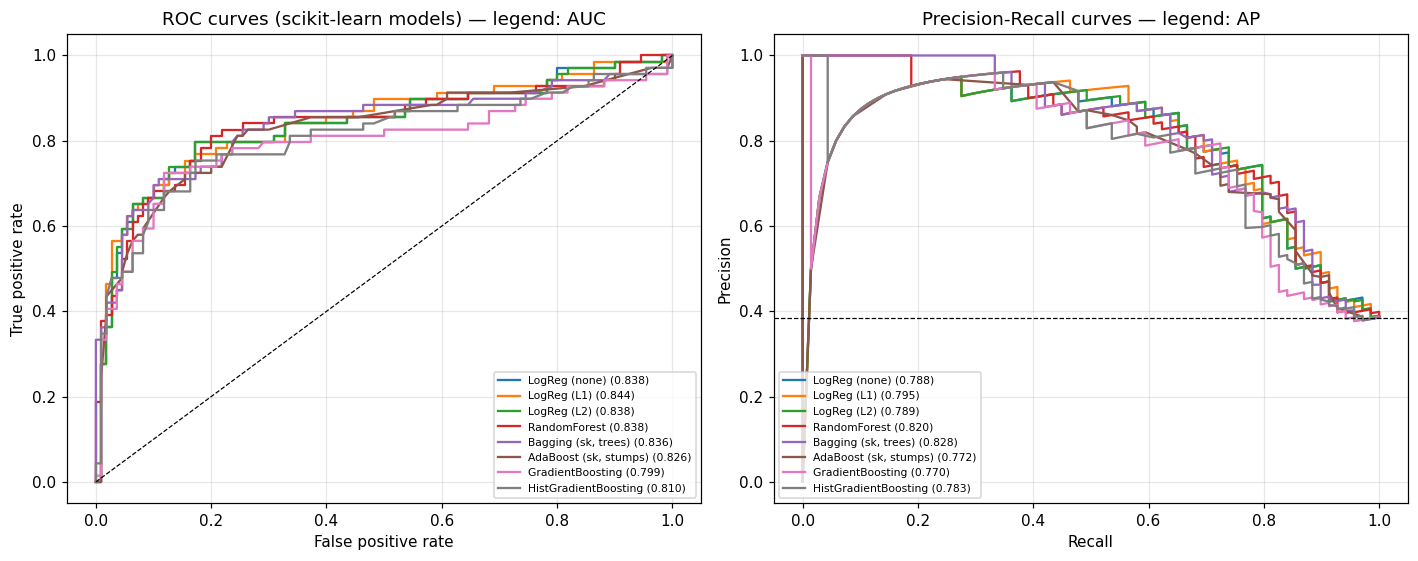

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
for name in names:
    fpr, tpr, _ = roc_curve(y_test, probs[name]); ax[0].plot(fpr, tpr, label=f"{name} ({results[name]['roc_auc']:.3f})")
    pr, rc, _ = precision_recall_curve(y_test, probs[name]); ax[1].plot(rc, pr, label=f"{name} ({results[name]['avg_precision']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8); ax[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curves (scikit-learn models) — legend: AUC")
ax[1].axhline(y_test.mean(), c="k", ls="--", lw=0.8); ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curves — legend: AP")
ax[0].legend(fontsize=7, loc="lower right"); ax[1].legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.savefig("figs/C_roc_pr_curves.png", bbox_inches="tight"); plt.show()

## 7. Comparison table — from-scratch (Section B) vs. library (Section C)
All rows: same split, same seed, same metrics, same 0.5 threshold. Rows are paired by algorithm.

In [11]:
pairs = [("LogReg (none)", "LogReg (none)"), ("LogReg (L1)", "LogReg (L1)"), ("LogReg (L2)", "LogReg (L2)"), ("LogReg (L2)", "LogReg (L2, lambda=B)"),
         ("Bagging (trees)", "Bagging (sk, trees)"), ("Bagging (trees)", "RandomForest"),
         ("AdaBoost (stumps)", "AdaBoost (sk, stumps)")]
rows = []
for b, c in pairs:
    for impl, key, R, T in (("scratch (B)", b, RB["metrics"], RB["fit_time_s"]), ("sklearn (C)", c, results, fit_times)):
        rows.append({"algorithm": c if impl.startswith("sk") else b, "group": b if b != "Bagging (trees)" else "Bagging", "implementation": impl, **{m: R[key][m] for m in cols}, "fit_time_s": T[key]})
for k in ("GradientBoosting", "HistGradientBoosting"):
    rows.append({"algorithm": k, "group": "Boosting (library only)", "implementation": "sklearn (C)", **{m: results[k][m] for m in cols}, "fit_time_s": fit_times[k]})
comp = pd.DataFrame(rows).drop_duplicates(subset=["algorithm", "implementation"]).drop(columns="group")
comp = comp.set_index(["algorithm", "implementation"])
comp.round(4)

accuracy  precision  recall      f1  \
algorithm             implementation                                        
LogReg (none)         scratch (B)       0.7989     0.7797  0.6667  0.7188   
                      sklearn (C)       0.7989     0.7797  0.6667  0.7188   
LogReg (L1)           scratch (B)       0.8156     0.8103  0.6812  0.7402   
                      sklearn (C)       0.8156     0.8103  0.6812  0.7402   
LogReg (L2)           scratch (B)       0.8212     0.8364  0.6667  0.7419   
                      sklearn (C)       0.7989     0.7797  0.6667  0.7188   
LogReg (L2, lambda=B) sklearn (C)       0.8212     0.8364  0.6667  0.7419   
Bagging (trees)       scratch (B)       0.8156     0.8103  0.6812  0.7402   
Bagging (sk, trees)   sklearn (C)       0.8045     0.8696  0.5797  0.6957   
RandomForest          sklearn (C)       0.8156     0.8214  0.6667  0.7360   
AdaBoost (stumps)     scratch (B)       0.7989     0.7705  0.6812  0.7231   
AdaBoost (sk, stumps) sklearn (C)       0.7989     0.7705  0.6812  0.7231   
GradientBoosting      sklearn (C)       0.7821     0.7885  0.5942  0.6777   
HistGradientBoosting  sklearn (C)       0.7989     0.8000  0.6377  0.7097   

                                      roc_auc  avg_precision     mcc  \
algorithm             implementation                                   
LogReg (none)         scratch (B)      0.8379         0.7882  0.5679   
                      sklearn (C)      0.8379         0.7882  0.5679   
LogReg (L1)           scratch (B)      0.8436         0.7948  0.6044   
                      sklearn (C)      0.8436         0.7948  0.6044   
LogReg (L2)           scratch (B)      0.8378         0.7973  0.6170   
                      sklearn (C)      0.8381         0.7889  0.5679   
LogReg (L2, lambda=B) sklearn (C)      0.8378         0.7973  0.6170   
Bagging (trees)       scratch (B)      0.8457         0.8260  0.6044   
Bagging (sk, trees)   sklearn (C)      0.8363         0.8279  0.5849   
RandomForest          sklearn (C)      0.8382         0.8204  0.6044   
AdaBoost (stumps)     scratch (B)      0.7949         0.7636  0.5688   
AdaBoost (sk, stumps) sklearn (C)      0.8263         0.7725  0.5688   
GradientBoosting      sklearn (C)      0.7987         0.7697  0.5298   
HistGradientBoosting  sklearn (C)      0.8105         0.7830  0.5672   

                                      balanced_accuracy  log_loss  fit_time_s  
algorithm             implementation                                           
LogReg (none)         scratch (B)                0.7742    0.4670      0.0595  
                      sklearn (C)                0.7742    0.4670      0.0262  
LogReg (L1)           scratch (B)                0.7906    0.4642      0.0705  
                      sklearn (C)                0.7906    0.4642      0.2742  
LogReg (L2)           scratch (B)                0.7924    0.4759      0.0257  
                      sklearn (C)                0.7742    0.4669      0.1394  
LogReg (L2, lambda=B) sklearn (C)                0.7924    0.4759      0.0027  
Bagging (trees)       scratch (B)                0.7906    0.4596      3.1698  
Bagging (sk, trees)   sklearn (C)                0.7626    0.4485     10.4497  
RandomForest          sklearn (C)                0.7879    0.4665     66.0717  
AdaBoost (stumps)     scratch (B)                0.7769    0.5481      0.0981  
AdaBoost (sk, stumps) sklearn (C)                0.7769    0.6028      6.5248  
GradientBoosting      sklearn (C)                0.7471    0.5201     11.3753  
HistGradientBoosting  sklearn (C)                0.7688    0.5112      9.7420

> **Reading the table.** *Scratch* fit times are the time to train the **final** model only (tuning was done earlier in Section B), whereas *sklearn* fit times **include the `GridSearchCV` search** (e.g. 36 configurations × 5 folds for the random forest), so the two timing columns are not directly comparable. `LogReg (L2, lambda=B)` is scikit-learn trained with exactly B's selected λ (mapped through `C = 1/(nλ)`); the plain `LogReg (L2)` row uses the λ that scikit-learn's own grid search preferred. CV-AUC is almost flat across λ for logistic regression, so the two searches (different fold assignments) legitimately land on different λ.

In [12]:
# side-by-side deltas for the algorithm pairs (sklearn minus scratch)
delta = []
for b, c in pairs:
    delta.append({"scratch model": b, "library model": c, **{f"Δ{m}": results[c][m] - RB["metrics"][b][m] for m in ("accuracy", "f1", "roc_auc", "avg_precision", "log_loss")}})
pd.DataFrame(delta).set_index(["scratch model", "library model"]).round(4)

Δaccuracy     Δf1  Δroc_auc  \
scratch model     library model                                        
LogReg (none)     LogReg (none)             0.0000  0.0000   -0.0000   
LogReg (L1)       LogReg (L1)               0.0000  0.0000   -0.0000   
LogReg (L2)       LogReg (L2)              -0.0223 -0.0232    0.0003   
                  LogReg (L2, lambda=B)     0.0000  0.0000   -0.0000   
Bagging (trees)   Bagging (sk, trees)      -0.0112 -0.0445   -0.0094   
                  RandomForest              0.0000 -0.0042   -0.0075   
AdaBoost (stumps) AdaBoost (sk, stumps)     0.0000  0.0000    0.0314   

                                         Δavg_precision  Δlog_loss  
scratch model     library model                                     
LogReg (none)     LogReg (none)                  0.0000     0.0000  
LogReg (L1)       LogReg (L1)                    0.0000     0.0000  
LogReg (L2)       LogReg (L2)                   -0.0085    -0.0090  
                  LogReg (L2, lambda=B)          0.0000     0.0000  
Bagging (trees)   Bagging (sk, trees)            0.0019    -0.0112  
                  RandomForest                  -0.0055     0.0069  
AdaBoost (stumps) AdaBoost (sk, stumps)          0.0089     0.0547

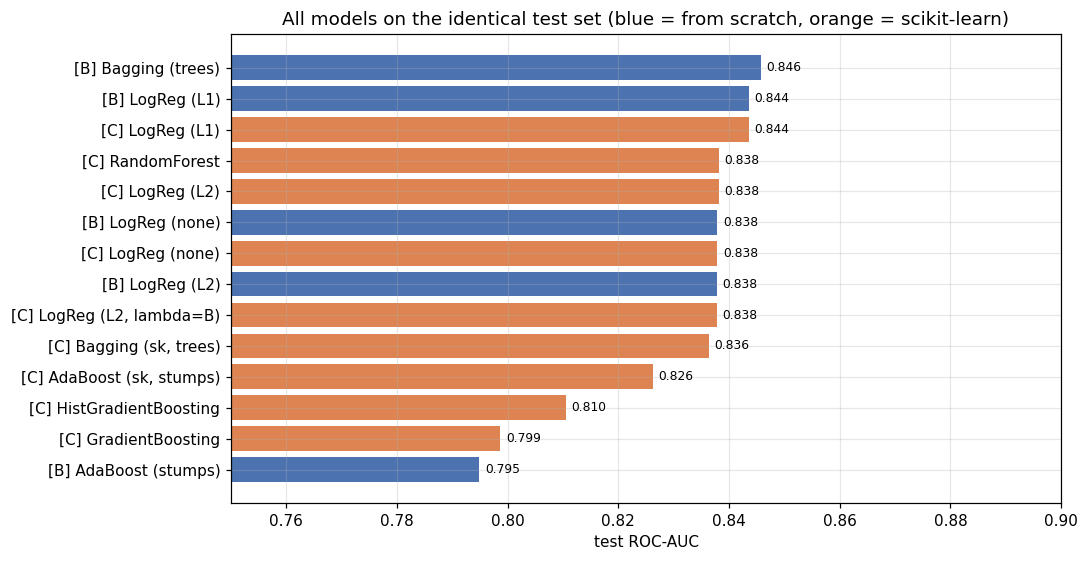

,roc_auc,accuracy,f1,avg_precision,log_loss
[B] Bagging (trees),0.8457,0.8156,0.7402,0.8260,0.4596
[B] LogReg (L1),0.8436,0.8156,0.7402,0.7948,0.4642
[C] LogReg (L1),0.8436,0.8156,0.7402,0.7948,0.4642
[C] RandomForest,0.8382,0.8156,0.7360,0.8204,0.4665
[C] LogReg (L2),0.8381,0.7989,0.7188,0.7889,0.4669
[B] LogReg (none),0.8379,0.7989,0.7188,0.7882,0.4670
[C] LogReg (none),0.8379,0.7989,0.7188,0.7882,0.4670
[B] LogReg (L2),0.8378,0.8212,0.7419,0.7973,0.4759
"[C] LogReg (L2, lambda=B)",0.8378,0.8212,0.7419,0.7973,0.4759
"[C] Bagging (sk, trees)",0.8363,0.8045,0.6957,0.8279,0.4485


In [13]:
# ranking of every model (scratch + library) by test ROC-AUC, with accuracy for reference
allm = {**{f"[B] {k}": v for k, v in RB["metrics"].items()}, **{f"[C] {k}": v for k, v in results.items()}}
rank = pd.DataFrame(allm).T[["roc_auc", "accuracy", "f1", "avg_precision", "log_loss"]].sort_values("roc_auc", ascending=False).round(4)
rank

fig, ax = plt.subplots(figsize=(10, 5.2)); r = rank.iloc[::-1]
colors = ["#4C72B0" if i.startswith("[B]") else "#DD8452" for i in r.index]
ax.barh(r.index, r["roc_auc"], color=colors); ax.set_xlim(0.75, 0.9); ax.set_xlabel("test ROC-AUC")
for y_, v in enumerate(r["roc_auc"]): ax.text(v + 0.001, y_, f"{v:.3f}", va="center", fontsize=8)
ax.set_title("All models on the identical test set (blue = from scratch, orange = scikit-learn)")
plt.tight_layout(); plt.savefig("figs/comparison_auc.png", bbox_inches="tight"); plt.show()
rank

## 8. How much should we trust small differences? (uncertainty on a 179-row test set)
One test passenger is worth 0.56 percentage points of accuracy, so gaps of 1–2 points are within noise. A **bootstrap over the test set** (1 000 resamples, fixed seed) gives a 95 % interval for accuracy and AUC; the 5-fold CV-AUC on the training set is an independent second opinion.

In [14]:
rng = np.random.default_rng(SEED)
idx = rng.integers(0, len(y_test), size=(1000, len(y_test)))
unc = []
for key, p, pr_ in [(f"[B] {k}", np.array(v), (np.array(v) >= .5).astype(int)) for k, v in RB["test_probabilities"].items()] + \
                   [(f"[C] {k}", probs[k], preds[k]) for k in probs]:
    accs = np.array([np.mean(pr_[i] == y_test[i]) for i in idx])
    aucs = np.array([roc_auc_score(y_test[i], p[i]) for i in idx if 0 < y_test[i].sum() < len(i)])
    unc.append({"model": key, "accuracy": np.mean(pr_ == y_test), "acc 95% CI": f"[{np.percentile(accs, 2.5):.3f}, {np.percentile(accs, 97.5):.3f}]",
                "AUC": roc_auc_score(y_test, p), "AUC 95% CI": f"[{np.percentile(aucs, 2.5):.3f}, {np.percentile(aucs, 97.5):.3f}]"})
unc = pd.DataFrame(unc).set_index("model"); unc[["accuracy", "AUC"]] = unc[["accuracy", "AUC"]].round(4)
cvtab = pd.Series(cv_auc, name="5-fold CV-AUC (train, library models)").round(4)
display(unc); display(cvtab.to_frame())

,accuracy,acc 95% CI,AUC,AUC 95% CI
model,,,,
[B] LogReg (none),0.7989,"[0.743, 0.855]",0.8379,"[0.769, 0.897]"
[B] LogReg (L1),0.8156,"[0.760, 0.872]",0.8436,"[0.775, 0.902]"
[B] LogReg (L2),0.8212,"[0.765, 0.872]",0.8378,"[0.770, 0.899]"
[B] Bagging (trees),0.8156,"[0.754, 0.872]",0.8457,"[0.775, 0.906]"
[B] AdaBoost (stumps),0.7989,"[0.737, 0.855]",0.7949,"[0.714, 0.866]"
[C] LogReg (none),0.7989,"[0.743, 0.855]",0.8379,"[0.769, 0.897]"
[C] LogReg (L1),0.8156,"[0.760, 0.872]",0.8436,"[0.775, 0.902]"
[C] LogReg (L2),0.7989,"[0.743, 0.855]",0.8381,"[0.769, 0.898]"
"[C] LogReg (L2, lambda=B)",0.8212,"[0.765, 0.872]",0.8378,"[0.770, 0.899]"


,"5-fold CV-AUC (train, library models)"
LogReg (none),0.8577
LogReg (L1),0.8579
LogReg (L2),0.8578
RandomForest,0.8795
"Bagging (sk, trees)",0.8705
"AdaBoost (sk, stumps)",0.8668
GradientBoosting,0.8854
HistGradientBoosting,0.8830


## 9. Save results and note performance

In [15]:
total = time.perf_counter() - NB_START
print(f"Total wall-clock time of this notebook: {total:.1f} s  (limit: 300 s on CPU)")
print("Performance notes: n_jobs=1 for determinism and portability; grids are deliberately small; HistGradientBoosting uses early_stopping=False so results do not depend on an internal random validation split.")

comp.round(6).to_csv("data/results/comparison_table.csv")
with open("data/results/results_C.json", "w") as fh:
    json.dump({"metrics": results, "best_params": {k: {a: (b if not isinstance(b, (np.generic,)) else b.item()) for a, b in v.items()} for k, v in best_params.items()},
               "cv_auc": cv_auc, "fit_time_s": fit_times, "notebook_runtime_s": total,
               "bootstrap_ci": unc.to_dict(orient="index"), "versions": {"numpy": np.__version__, "pandas": pd.__version__, "sklearn": sklearn.__version__, "matplotlib": matplotlib.__version__}}, fh, default=str)
print("saved data/results/comparison_table.csv and results_C.json")

Total wall-clock time of this notebook: 120.6 s  (limit: 300 s on CPU)
Performance notes: n_jobs=1 for determinism and portability; grids are deliberately small; HistGradientBoosting uses early_stopping=False so results do not depend on an internal random validation split.
saved data/results/comparison_table.csv and results_C.json
